In [53]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

# Rocket Parameters
g = 9.80665
pi = np.pi
rho = 1.225
ρ = 1.225 # Density

# Earth radius
R = 6371000 

launch_angle = 45
theta = np.radians(launch_angle)

m_prop = 0.3
isp = 300
m_total = 2.5

diameter = 0.1
A = pi * (diameter/2)**2

burn_time = 2.6
thrust_peak = 458

cd = 0.3

# Force Calculations

m = m_prop / burn_time # mass flow rate 
print(f"Mass flow rate: {m} Kg/s")

ve = isp / g  # Exit velocity
print(f"Exit velosity: {ve} m/s")

ta = isp / burn_time  # Thurst average
print(f"Thrust average: {ta} N")

ac = (ta / m_total) - g # m/s Accelerations
ab = (thrust_peak / burn_time) - g # Accelaration in bornout

w = m_total * g # weight in N
print(f"Weight in N: {w} N")

a = (pi*A) / 4 #Area
print(f"Area of body:{a}m^2")

fnet = m_total * a # Net force
print(f"Net force:{fnet} N")

d = cd * (0.5*ρ)*(ve**(2*a)) # Drag force
print(f"Drag of the body: {d} N")

vt = np.sqrt((2*m_total*g) / (ρ*cd*a))
print(f"Terminal velocity: {vt} M/s")

amp = thrust_peak - ta

# Derived Values

mdot = m_prop / burn_time
ve = isp * g

thrust_avg = thrust_peak * 0.7   



Mass flow rate: 0.11538461538461538 Kg/s
Exit velosity: 30.59148638933785 m/s
Thrust average: 115.38461538461539 N
Weight in N: 24.516624999999998 N
Area of body:0.006168502750680849m^2
Net force:0.015421256876702124 N
Drag of the body: 0.1916704710929122 N
Terminal velocity: 147.07091245802317 M/s


In [54]:
# Simulation Setup

dt = 0.1
t_max = 60

x, y = 0.0, 0.0
vx, vy = 0.0, 0.0
v = v = 1e-6  #  avoid zero at start

x_list, y_list = [], []
v_list, pitch_list = [], []
lat_list,lon_list = [], []

# Simulation Loop

for t in np.arange(0, t_max, dt):

    # Velocity magnitude FIRST
    v = np.sqrt(vx**2 + vy**2)

    # Pitch angle FIX
    if t == 0:
        pitch_angle = theta
    else:
        pitch_angle = np.arctan2(vy, vx)

    # Drag force
    drag = 0.5 * rho * cd * A * v**2
    
    if v == 0:
        drag_x = 0
        drag_y = 0
    else:
        drag_x = drag * (vx / v)
        drag_y = drag * (vy / v)


    # BEFORE BURNOUT

    if t <= burn_time:

        thrust = thrust_avg + (thrust_peak - thrust_avg) * np.sin(pi * t / burn_time)

        mass = m_total - mdot * t
    
      # thrust direction
        # thrust_x = thrust * np.cos(pitch_angle)
        # thrust_y = thrust * np.sin(pitch_angle)


        # Acceleration at time
        a = (thrust - drag - (mass * g)) / mass
        ax = a * np.cos(pitch_angle)
        ay = a * np.sin(pitch_angle)

        # velocity at time
        vx = vx + ax * dt
        vy = vy + ay * dt
        v = np.sqrt(vx**2 + vy**2) + 1e-6

        # potion at time 
        x = x + vx * dt + 0.5 * ax * dt**2
        y = y + vy * dt + 0.5 * ay * dt**2

    # AFTER BURNOUT
  
    else:

        thrust = 0
        mass = m_total - m_prop

        # Acceleration at time
        ax = -drag_x / mass
        ay = -drag_y / mass - g

        # velocity at time
        vx = vx + ax * dt
        vy = vy + ay * dt
        

        # potion at time 
        x = x + vx * dt
        y = y + vy * dt

    # Dynamic Pressure
    q = 0.5 * rho * v**2

    v_list.append(v)
    x_list.append(x)
    y_list.append(y)
    pitch_list.append(pitch_angle)
  

    if y < 0 and t > 1:
        break


In [55]:
# Rocket co-ardinates

lati = 12.995182   # initial latitude
longi = 80.167285  # initial longitude
direction = 30     # degrees (launch azimuth) 


lat0 = np.radians(lati)
lon0 = np.radians(longi)

for x in x_list:

    # Convert direction
    theta = np.radians(direction)

    # Decompose distance
    east = x * np.cos(theta)
    north = x * np.sin(theta)

    # Convert to lat/lon
    dlat = north / R
    dlon = east / (R * np.cos(lat0))

    lat = lat0 + dlat
    lon = lon0 + dlon

    # Convert back to degrees
    lat_list.append(np.degrees(lat))
    lon_list.append(np.degrees(lon))

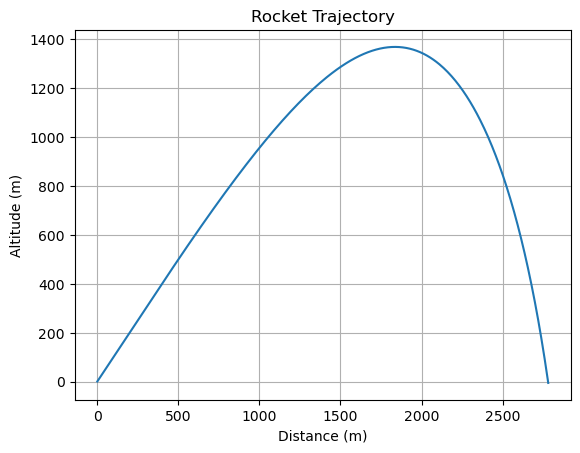

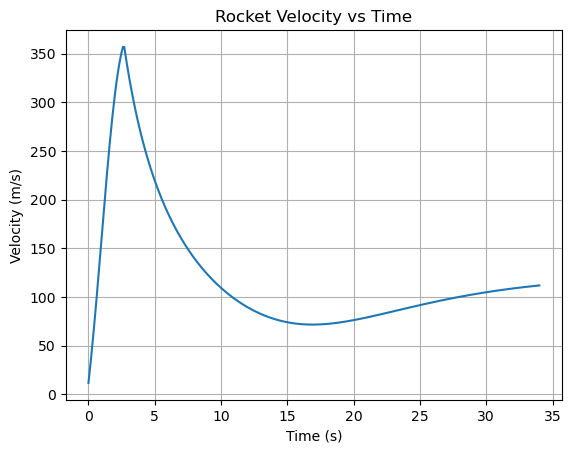

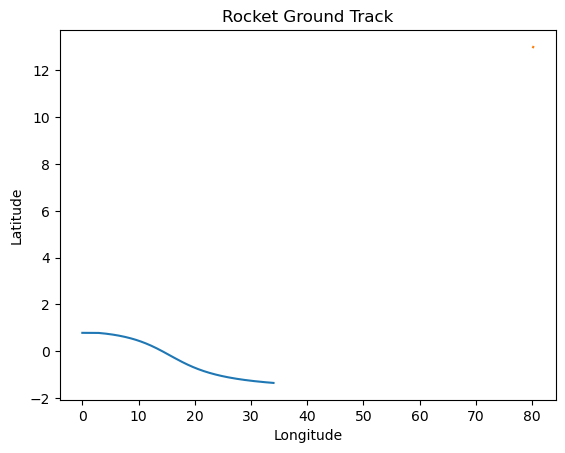

ModuleNotFoundError: No module named 'openpyxl'

In [57]:
# Plot 1: Trajectory
plt.figure()

plt.plot(x_list, y_list)
plt.xlabel("Distance (m)")
plt.ylabel("Altitude (m)")
plt.title("Rocket Trajectory")
plt.grid()


# Plot 2: Velocity vs Time
plt.figure()

time = np.arange(0, len(v_list)*dt, dt)

plt.plot(time, v_list)
plt.xlabel("Time (s)")
plt.ylabel("Velocity (m/s)")
plt.title("Rocket Velocity vs Time")
plt.grid()


# Plot 3: Pitch Angle vs Time
plt.figure()

plt.plot(time, pitch_list)
plt.xlabel("Time (s)")
plt.ylabel("Pitch Angle (rad)")
plt.title("Pitch Angle vs Time")
plt.grid()

plt.plot(lon_list, lat_list)
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.title("Rocket Ground Track")
plt.grid()

plt.show()

# Create DataFrame
data = pd.DataFrame({
    "Time (s)": time,
    "X (m)": x_list,
    "Y (m)": y_list,
    "Velocity (m/s)": v_list,
    "Pitch Angle (deg)": np.degrees(pitch_list),
    "Longitude": lon_list,
    "Latitude": lat_list
})

# Save to Excel
data.to_excel(f"rocket_{launch_angle}deg_{int(thrust_peak)}N.xlsx", index=False)

print("Excel file saved as rocket_trajectory.xlsx")